In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip /content/drive/MyDrive/DL/SDNET2018.zip -d /content/SDNET2018

Streaming output truncated to the last 5000 lines.
  inflating: /content/SDNET2018/D/UD/7032-171.jpg  
  inflating: /content/SDNET2018/D/UD/7032-172.jpg  
  inflating: /content/SDNET2018/D/UD/7032-173.jpg  
  inflating: /content/SDNET2018/D/UD/7032-174.jpg  
  inflating: /content/SDNET2018/D/UD/7032-175.jpg  
  inflating: /content/SDNET2018/D/UD/7032-176.jpg  
  inflating: /content/SDNET2018/D/UD/7032-177.jpg  
  inflating: /content/SDNET2018/D/UD/7032-178.jpg  
  inflating: /content/SDNET2018/D/UD/7032-179.jpg  
  inflating: /content/SDNET2018/D/UD/7032-18.jpg  
  inflating: /content/SDNET2018/D/UD/7032-180.jpg  
  inflating: /content/SDNET2018/D/UD/7032-181.jpg  
  inflating: /content/SDNET2018/D/UD/7032-182.jpg  
  inflating: /content/SDNET2018/D/UD/7032-183.jpg  
  inflating: /content/SDNET2018/D/UD/7032-184.jpg  
  inflating: /content/SDNET2018/D/UD/7032-185.jpg  
  inflating: /content/SDNET2018/D/UD/7032-186.jpg  
  inflating: /content/SDNET2018/D/UD/7032-187.jpg  
  inflating: /

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import importlib
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from torch.utils.data import DataLoader

import src.dataset as _ds_mod; importlib.reload(_ds_mod)
from src.dataset     import CrackDataset, load_splits
from src.models      import DeepSVDDWithNorm
from src.train_utils import (train_svdd_epoch, eval_scores,
                              calibrate_threshold, compute_metrics,
                              print_metrics, save_checkpoint, load_checkpoint)
from src.viz_utils   import (plot_loss_curves, plot_roc_curve, plot_pr_curve,
                              plot_confusion_matrix, plot_score_histogram,
                              plot_patches_grid, plot_tsne)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

SPLITS_DIR      = 'splits'
CHECKPOINTS_DIR = 'checkpoints'
RESULTS_DIR     = 'results'
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)


Device : cuda


## 1. Configuration & Data Loading

In [4]:
train_records, val_records, test_records = load_splits(SPLITS_DIR)

PREPROCESSING = 'none'   # 'lime' | 'clahe' | 'none'
BATCH_SIZE    = 64

train_normal_ds = CrackDataset(train_records, preprocessing=PREPROCESSING,
                               augment=True,  normal_only=True)
val_ds          = CrackDataset(val_records,   preprocessing=PREPROCESSING)
test_ds         = CrackDataset(test_records,  preprocessing=PREPROCESSING)

train_normal_loader = DataLoader(train_normal_ds, batch_size=BATCH_SIZE,
                                  shuffle=True,  num_workers=0, pin_memory=False)
val_loader          = DataLoader(val_ds,          batch_size=BATCH_SIZE,
                                  shuffle=False, num_workers=0, pin_memory=False)
test_loader         = DataLoader(test_ds,         batch_size=BATCH_SIZE,
                                  shuffle=False, num_workers=0, pin_memory=False)

print(f'Train (normal only) : {len(train_normal_ds):,}')
print(f'Val                 : {len(val_ds):,}')
print(f'Test                : {len(test_ds):,}')


Train (normal only) : 15,207
Val                 : 3,650
Test                : 3,651


In [5]:
model = DeepSVDDWithNorm(
    freeze_up_to  = 'layer2',   # freeze layers 1-2, fine-tune layers 3-4
    hidden_dims   = [256],      # projection head: 512 → 256 → 64
    out_dim       = 64,
    use_bn        = False,      # NO BatchNorm causes hypersphere collapse
    dropout       = 0.0,
    pretrained    = True,
).to(device)

print(model)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 201MB/s]


DeepSVDDWithNorm(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_st

In [6]:
print('Initialising hypersphere centre c ...')
model.init_centre(train_normal_loader, device)

Initialising hypersphere centre c ...


init_centre (buggy): 100%|██████████| 238/238 [02:51<00:00,  1.39it/s]

  Centre norm: 1.0428  (expect ≈1.0 due to F.normalize bug)


In [7]:
NUM_EPOCHS  = 15
LR          = 1e-4
WEIGHT_DECAY= 1e-4
PATIENCE    = 3

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

train_losses     = []
best_loss        = float('inf')
epochs_no_improve = 0

print(f'Training Deep SVDD for up to {NUM_EPOCHS} epochs on {device}...')
print(f'{"Epoch":>6}  {"Train Loss":>12}')

for epoch in range(NUM_EPOCHS):
    loss = train_svdd_epoch(model, train_normal_loader, optimizer, device)
    scheduler.step()
    train_losses.append(loss)
    print(f'[{epoch+1:>3}/{NUM_EPOCHS}]  Loss: {loss:.6f}')

    if loss < best_loss:
        best_loss = loss
        epochs_no_improve = 0
        save_checkpoint(model, f'{CHECKPOINTS_DIR}/deep_svdd.pth',
                        extra={'train_losses': train_losses, 'num_epochs': epoch + 1})
        print(f'           ↑ saved (loss={best_loss:.6f})')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch+1} (no improvement for {PATIENCE} epochs).')
            break

print('\nTraining complete.')

Training Deep SVDD for up to 15 epochs on cuda...
 Epoch    Train Loss
[  1/15]  Loss: 0.024093
  Saved checkpoint → checkpoints/deep_svdd.pth
           ↑ saved (loss=0.024093)
[  2/15]  Loss: 0.002077
  Saved checkpoint → checkpoints/deep_svdd.pth
           ↑ saved (loss=0.002077)
[  3/15]  Loss: 0.001936
  Saved checkpoint → checkpoints/deep_svdd.pth
           ↑ saved (loss=0.001936)
[  4/15]  Loss: 0.001893
  Saved checkpoint → checkpoints/deep_svdd.pth
           ↑ saved (loss=0.001893)
[  5/15]  Loss: 0.001872
  Saved checkpoint → checkpoints/deep_svdd.pth
           ↑ saved (loss=0.001872)
[  6/15]  Loss: 0.001861
  Saved checkpoint → checkpoints/deep_svdd.pth
           ↑ saved (loss=0.001861)
[  7/15]  Loss: 0.001854
  Saved checkpoint → checkpoints/deep_svdd.pth
           ↑ saved (loss=0.001854)
[  8/15]  Loss: 0.001850
  Saved checkpoint → checkpoints/deep_svdd.pth
           ↑ saved (loss=0.001850)
[  9/15]  Loss: 0.001847
  Saved checkpoint → checkpoints/deep_svdd.pth
 

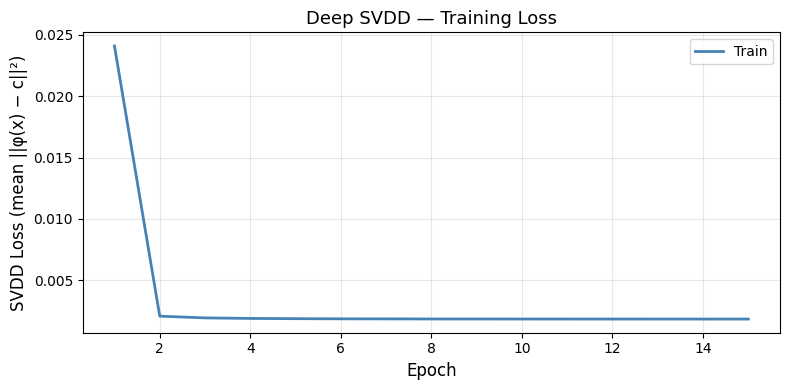

In [8]:
ax = plot_loss_curves(train_losses, title='Deep SVDD — Training Loss',
                      ylabel='SVDD Loss (mean ||φ(x) − c||²)')
plt.tight_layout()
plt.show()

Computing validation anomaly scores...

Best threshold τ = 0.001841  (val F1 = 0.2169)


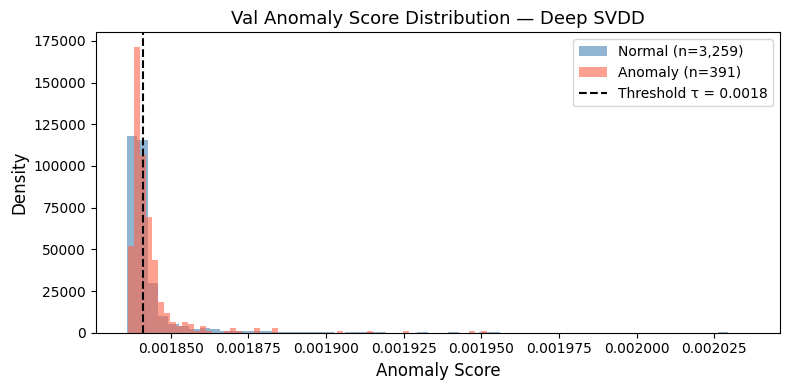

In [9]:
print('Computing validation anomaly scores...')
val_scores, val_labels = eval_scores(model, val_loader, device)

tau, val_f1 = calibrate_threshold(val_scores, val_labels)
print(f'\nBest threshold τ = {tau:.6f}  (val F1 = {val_f1:.4f})')

ax = plot_score_histogram(val_scores, val_labels, threshold=tau,
                          title='Val Anomaly Score Distribution — Deep SVDD')
plt.tight_layout()
plt.show()

In [10]:
print('Computing test anomaly scores...')
test_scores, test_labels = eval_scores(model, test_loader, device)

metrics = compute_metrics(test_scores, test_labels, tau)
print_metrics(metrics, model_name='Deep SVDD')


results = {
    'scores': test_scores, 'labels': test_labels,
    'threshold': tau,
    **{k: v for k, v in metrics.items() if k != 'preds'},
    'train_losses': train_losses,
}
with open(f'{RESULTS_DIR}/results_deep_svdd_norm.pkl', 'wb') as f:
    pickle.dump(results, f)
print('Results saved.')

Computing test anomaly scores...
[Deep SVDD] AUROC: 0.5781  AUPRC: 0.1287  F1: 0.2077
  Confusion matrix:
    TN=  2141  FP=  1119
    FN=   216  TP=   175
Results saved.


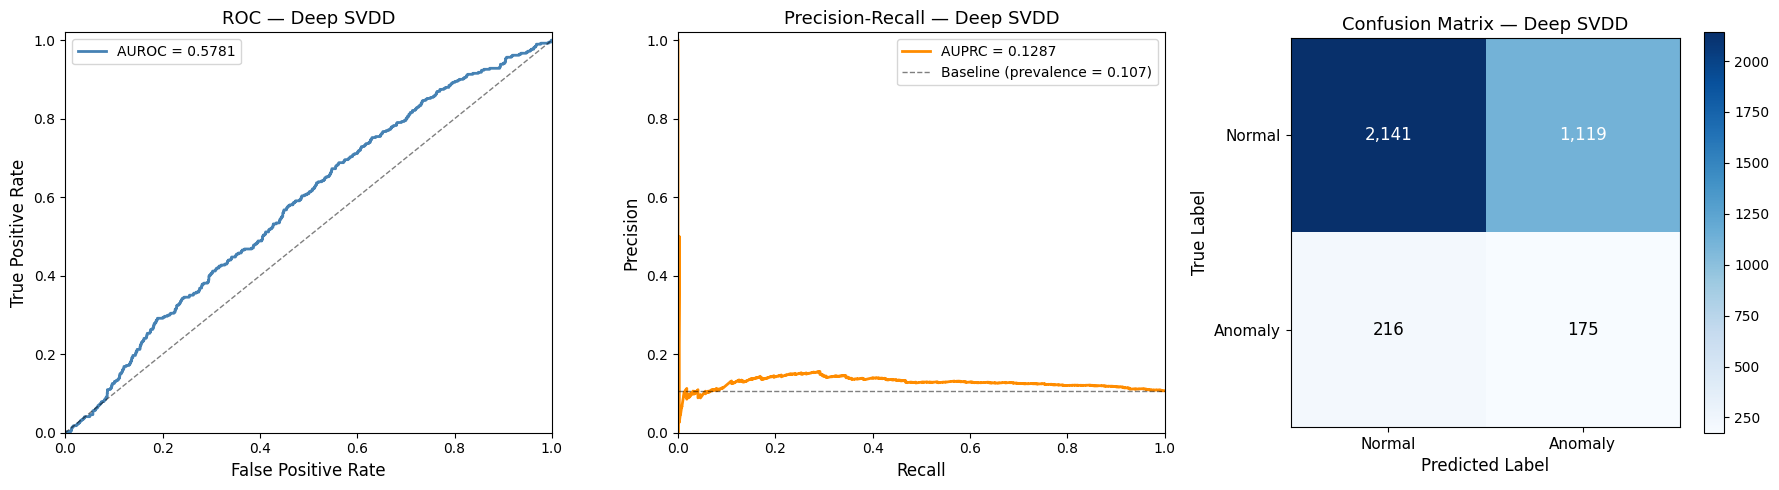

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_roc_curve(test_scores, test_labels, metrics['auroc'],
               title='ROC — Deep SVDD', ax=axes[0])
plot_pr_curve(test_scores, test_labels, metrics['auprc'],
              title='Precision-Recall — Deep SVDD', ax=axes[1])
plot_confusion_matrix(metrics['cm'], title='Confusion Matrix — Deep SVDD', ax=axes[2])

plt.tight_layout()
plt.show()

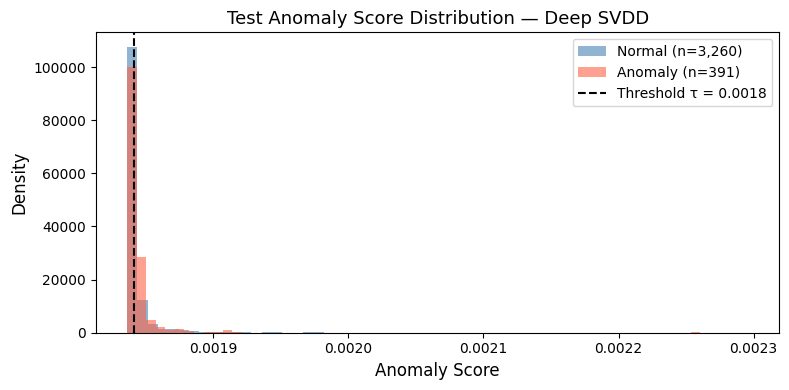

In [12]:
ax = plot_score_histogram(test_scores, test_labels, threshold=tau,
                          title='Test Anomaly Score Distribution — Deep SVDD')
plt.tight_layout()
plt.show()

- F.normalize in forward pass — forces all embeddings onto unit sphere

- bias=True in Linear layers — allows weights→0, bias→c trivial solution


In [13]:
from google.colab import files
import os

def download_files_from_dir(directory):
    """Downloads all files from a given directory."""
    if not os.path.exists(directory):
        print(f"Directory '{directory}' does not exist.")
        return

    print(f"Downloading files from {directory}...")
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        if os.path.isfile(filepath):
            try:
                files.download(filepath)
                print(f"  Downloaded: {filename}")
            except Exception as e:
                print(f"  Error downloading {filename}: {e}")

# Download files from checkpoints directory
download_files_from_dir(CHECKPOINTS_DIR)

# Download files from results directory
download_files_from_dir(RESULTS_DIR)

print("Download process complete.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: deep_svdd.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: results_deep_svdd_norm.pkl
Download process complete.
